In [58]:
from pathlib import Path
import pickle
import itertools
import os
import json
from itertools import combinations
from collections import Counter
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
import ast

converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

num_subjects = 10
num_trials = 17
trial_numbers = np.arange(1, num_trials + 1)
max_submissions = 5

scores = np.full((num_subjects, num_trials), np.nan)
diffs = np.full((num_subjects, num_trials), np.nan)
slopes_score = np.full(num_subjects, np.nan)
slopes_diff = np.full(num_subjects, np.nan)
median_scores = np.full(num_subjects, np.nan)
max_scores = np.full(num_subjects, np.nan)
fitted_scores = np.full((num_subjects, num_trials), np.nan)
fitted_diffs = np.full((num_subjects, num_trials), np.nan)

for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        scores[sub_id, trial_id - 1] = df["server_result.score"].iloc[-1]

        slider_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_maxs"])
        ])
        rec_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["server_result.rec"], df["slider_maxs"])
        ])
        diff_values_frac = np.round(slider_values_frac - rec_values_frac, 2)
        diffs[sub_id, trial_id - 1] = np.abs(diff_values_frac).sum()

    slope_score, intercept_score = np.polyfit(
        trial_numbers, scores[sub_id], 1
    )
    log_diffs = np.log(diffs[sub_id])
    slope_diff, intercept_diff = np.polyfit(
        trial_numbers, log_diffs, 1
    )
    fitted_scores[sub_id] = slope_score * trial_numbers + intercept_score
    fitted_diffs[sub_id] = np.exp(slope_diff * trial_numbers + intercept_diff)
    slopes_score[sub_id] = slope_score
    slopes_diff[sub_id] = slope_diff
    median_scores[sub_id] = np.nanmedian(scores[sub_id])
    max_scores[sub_id] = np.nanmax(scores[sub_id])

In [66]:
import importlib
import new_solution_scoring
import mrs

importlib.reload(new_solution_scoring)
importlib.reload(mrs)

from new_solution_scoring import (
    load_front_and_solution,
    compute_matchup_outcomes,
    compute_coalition_coverage,
)
from mrs import (
    density_filter,
    _safe_iqr
)

num_subjects = 10
num_trials = 17

converters = {
    "recommended_values": ast.literal_eval,
    "objective_names": ast.literal_eval,
}
sub_data_all = pd.read_csv('data/sub_data_all.csv', converters=converters)

subject_mapping = (
    sub_data_all[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

records = []

for row in subject_mapping.itertuples(index=False):
    for trial_id in range(1, num_trials + 1):
        sub_id = int(row.sub_id)
        print("sub:", sub_id, "trial:", trial_id)

        new_solution = sub_data_all.loc[
            (sub_data_all["sub_id"] == sub_id) &
            (sub_data_all["trial_id"] == trial_id)
        ]["recommended_values"].iloc[-1]
        objectives = sub_data_all["objective_names"].iloc[0]

        pareto_path = f"data/game_data/pf_block_2_trial_{trial_id}_*.csv"
        X_full, new, objectives = load_front_and_solution(
            pareto_path, objectives, new_solution
        )
        # X, _ = density_filter(X_full, 0.8)

        new_wins, front_win, draws, gt, wins_j, m, win_pct = compute_matchup_outcomes(X, new)
        coalitions, coverage, total_wins = compute_coalition_coverage(gt, new_wins, objectives, m)

        record = {
            "sub_id": sub_id,
            "trial_id": trial_id,
            "win_pct": win_pct,
        }

        if total_wins > 0:
            winning = max(coalitions, key=lambda c: coverage[c["bitmask"]])
            record["winning_coalition_label"] = winning["label"]
            record["winning_coalition_indices"] = winning["indices"]
        else:
            record["winning_coalition_label"] = None
            record["winning_coalition_indices"] = None

        for c in coalitions:
            col = f"coalition_coverage_pct_{c['label']}"
            record[col] = coverage[c["bitmask"]] / total_wins if total_wins else 0.0

        records.append(record)

id_cols = ["sub_id", "trial_id", "winning_coalition_label", "winning_coalition_indices", "win_pct"]
results_df = pd.DataFrame(records)
coverage_cols = [c for c in results_df.columns if c.startswith("coalition_coverage_pct_")]
results_df = results_df[id_cols + coverage_cols]

coverage_cols = [c for c in results_df.columns if c.startswith("coalition_coverage_pct_")]
prefix = "coalition_coverage_pct_"

label_to_indices = (
    results_df.dropna(subset=["winning_coalition_label"])
    .drop_duplicates("winning_coalition_label")
    .set_index("winning_coalition_label")["winning_coalition_indices"]
    .to_dict()
)

grouped = results_df.groupby("sub_id", sort=True)
mean_win_pct = grouped["win_pct"].mean()
mean_coverage = grouped[coverage_cols].mean()
sum_coverage = grouped[coverage_cols].sum()

winning_col = sum_coverage.idxmax(axis=1)
winning_label = winning_col.str[len(prefix):]

mean_results_df = pd.DataFrame({
    "sub_id": mean_win_pct.index,
    "mean_win_pct": mean_win_pct.values,
    "mean_winning_coalition_label": winning_label.values,
    "mean_winning_coalition_indices": winning_label.map(label_to_indices).values,
})
for c in coverage_cols:
    label = c[len(prefix):]
    mean_results_df[f"mean_coalition_coverage_pct_{label}"] = mean_coverage[c].values

sub: 0 trial: 1
sub: 0 trial: 2
sub: 0 trial: 3
sub: 0 trial: 4
sub: 0 trial: 5
sub: 0 trial: 6
sub: 0 trial: 7
sub: 0 trial: 8
sub: 0 trial: 9
sub: 0 trial: 10
sub: 0 trial: 11
sub: 0 trial: 12
sub: 0 trial: 13
sub: 0 trial: 14
sub: 0 trial: 15
sub: 0 trial: 16
sub: 0 trial: 17
sub: 1 trial: 1
sub: 1 trial: 2
sub: 1 trial: 3
sub: 1 trial: 4
sub: 1 trial: 5
sub: 1 trial: 6
sub: 1 trial: 7
sub: 1 trial: 8
sub: 1 trial: 9
sub: 1 trial: 10
sub: 1 trial: 11
sub: 1 trial: 12
sub: 1 trial: 13
sub: 1 trial: 14
sub: 1 trial: 15
sub: 1 trial: 16
sub: 1 trial: 17
sub: 2 trial: 1
sub: 2 trial: 2
sub: 2 trial: 3
sub: 2 trial: 4
sub: 2 trial: 5
sub: 2 trial: 6
sub: 2 trial: 7
sub: 2 trial: 8
sub: 2 trial: 9
sub: 2 trial: 10
sub: 2 trial: 11
sub: 2 trial: 12
sub: 2 trial: 13
sub: 2 trial: 14
sub: 2 trial: 15
sub: 2 trial: 16
sub: 2 trial: 17
sub: 3 trial: 1
sub: 3 trial: 2
sub: 3 trial: 3
sub: 3 trial: 4
sub: 3 trial: 5
sub: 3 trial: 6
sub: 3 trial: 7
sub: 3 trial: 8
sub: 3 trial: 9
sub: 3 trial: 10

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(4, 4))
subject_ids = np.arange(num_subjects)
subject_labels = np.arange(1, num_subjects + 1)
CONDITION_COLORS_2 = [
    "#668F8C",  # muted teal
    "#9A8173",  # warm taupe
]

axes[0].bar(
    subject_ids,
    slopes_score,
    width=0.6,
    color=CONDITION_COLORS_2[0],
    edgecolor=CONDITION_COLORS_2[0],
    linewidth=1.5,
)
axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(
    ylabel="Slope of score vs. trial",
)
axes[0].tick_params(axis="x", bottom=False, labelbottom=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(
    subject_ids,
    slopes_diff,
    width=0.6,
    color=CONDITION_COLORS_2[1],
    edgecolor=CONDITION_COLORS_2[1],
    linewidth=1.5,
)
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].set(
    xlabel="Subjects",
    ylabel="Slope of log distance\nbetween desired and recommended\nsolutions vs. trial",
)
axes[1].set_xticks(subject_ids)
axes[1].set_xticklabels(np.arange(1, num_subjects + 1))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("score_diff_col.png", dpi=300, bbox_inches="tight")


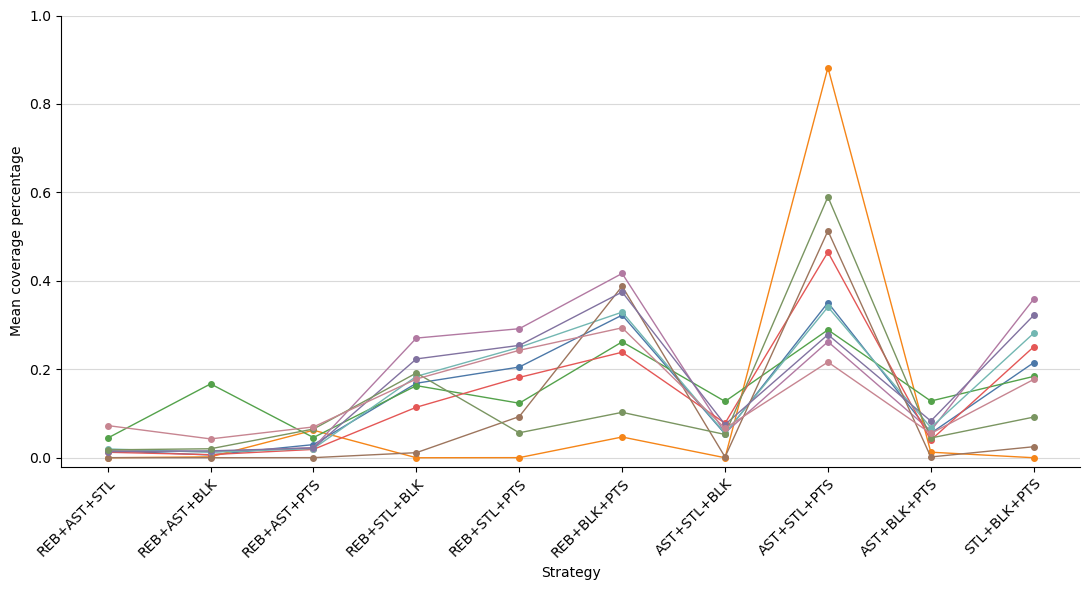

In [5]:
OBJ_COLORS = [
    "#4C78A8",   # blue
    "#F58518",   # orange
    "#54A24B",   # green
    "#E45756",   # red
    "#B279A2",   # purple

    # Additional colors
    "#72B7B2",   # teal
    "#FF9DA6",   # pink
    "#9D755D",   # brown
    "#BAB0AC",   # warm gray
    "#EDC948",   # yellow
]
LINE_COLORS_20 = [
    "#4C78A8",  # blue
    "#F58518",  # orange
    "#54A24B",  # green
    "#B279A2",  # purple
    "#E45756",  # red
    "#72B7B2",  # teal
    "#9D755D",  # brown
    "#8172A0",  # muted violet
    "#7A9561",  # sage
    "#C78591",  # dusty rose
    "#61788A",  # slate
    "#C07A52",  # rust
    "#5F9290",  # dark teal
    "#A86464",  # brick
    "#B49A52",  # ochre
    "#7F8588",  # cool gray
    "#FF9DA6",  # pink
    "#806A58",  # taupe
    "#EDC948",  # yellow
    "#BAB0AC",  # warm gray
]

prefix = "mean_coalition_coverage_pct_"
coverage_cols = [c for c in mean_results_df.columns if c.startswith(prefix)]
coalition_labels = [c[len(prefix):] for c in coverage_cols]
x = np.arange(len(coalition_labels), dtype=float)
subject_colors = OBJ_COLORS[: len(mean_results_df)]

fig, ax = plt.subplots(figsize=(11, 6))
for i, (_, row) in enumerate(mean_results_df.iterrows()):
    values = row[coverage_cols].to_numpy(dtype=float)
    ax.plot(
            x, values,
            marker='o', ms=4, lw=1,
            color=LINE_COLORS_20[i % len(LINE_COLORS_20)],
        )
    # ax.scatter(
    #     x, values,
    #     color=subject_colors[i], s=50, zorder=3,
    #     edgecolors="white", linewidths=0.4,
    #     label=f"Subject {int(row.sub_id) + 1}",
    # )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", color="0.85", linewidth=0.8, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(coalition_labels, rotation=45, ha="right", va="top", rotation_mode="anchor")
ax.set_xlabel("Strategy")
ax.set_ylabel("Mean coverage percentage")
ax.set_ylim(-0.02, 1)
# ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


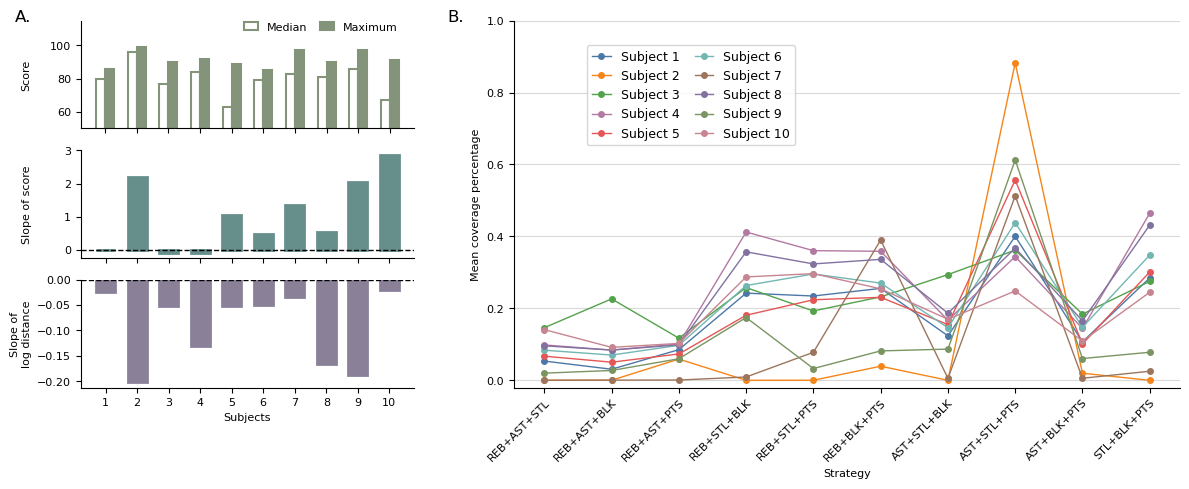

In [75]:
## final figure

from matplotlib.gridspec import GridSpec
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
})
CONDITION_COLORS_4 = [
    "#668F8C",  # muted teal
    "#8A8198",  # muted gray-purple
    "#687F9A",  # muted slate blue
    "#84947B",  # muted sage green
]
OBJ_COLORS = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2",
    "#72B7B2", "#FF9DA6", "#9D755D", "#BAB0AC", "#EDC948",
]
LINE_COLORS_20 = [
    "#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756",
    "#72B7B2", "#9D755D", "#8172A0", "#7A9561", "#C78591",
    "#61788A", "#C07A52", "#5F9290", "#A86464", "#B49A52",
    "#7F8588", "#FF9DA6", "#806A58", "#EDC948", "#BAB0AC",
]
prefix = "mean_coalition_coverage_pct_"
coverage_cols = [c for c in mean_results_df.columns if c.startswith(prefix)]
coalition_labels = [c[len(prefix):] for c in coverage_cols]
x = np.arange(len(coalition_labels), dtype=float)
subject_ids = np.arange(num_subjects)
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 2, figure=fig, width_ratios=[4, 8])
gs_left = gs[0].subgridspec(3, 1)
ax0 = fig.add_subplot(gs_left[0])
ax1 = fig.add_subplot(gs_left[1])
ax2 = fig.add_subplot(gs_left[2])
ax_ln = fig.add_subplot(gs[1])
# --- left: score summary and slope bars ---
bar_width = 0.28
ax0.bar(
    subject_ids - bar_width / 2, median_scores, width=bar_width,
    facecolor="none", edgecolor=CONDITION_COLORS_4[3], linewidth=1.5,
    label="Median",
)
ax0.bar(
    subject_ids + bar_width / 2, max_scores, width=bar_width,
    color=CONDITION_COLORS_4[3], edgecolor=CONDITION_COLORS_4[3], linewidth=1.5,
    label="Maximum",
)
ax0.set_ylim(50, 115)
ax0.set(ylabel="Score")
ax0.legend(
    frameon=False, loc="lower center", bbox_to_anchor=(0.72, 0.80),
    ncol=2, fontsize=8, columnspacing=1.2, handlelength=1.2,
)
ax0.tick_params(axis="x", labelbottom=False)
ax0.set_xticks(subject_ids)
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)
ax0.text(
    -0.2, 1.1, "A.",
    transform=ax0.transAxes,
    fontsize=12,
    va="top"
)
ax1.bar(
    subject_ids, slopes_score, width=0.6,
    color=CONDITION_COLORS_4[0], edgecolor=CONDITION_COLORS_4[0], linewidth=2,
)
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set(ylabel="Slope of score")
ax1.tick_params(axis="x", labelbottom=False)
ax1.set_xticks(subject_ids)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.bar(
    subject_ids, slopes_diff, width=0.6,
    color=CONDITION_COLORS_4[1], edgecolor=CONDITION_COLORS_4[1], linewidth=2,
)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set(
    xlabel="Subjects",
    ylabel="Slope of\nlog distance",
)
ax2.set_xticks(subject_ids)
ax2.set_xticklabels(np.arange(1, num_subjects + 1))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
for ax in (ax0, ax1, ax2):
    ax.locator_params(axis="y", nbins=5)
# --- right: coverage lines ---
coverage_df = mean_results_df.sort_values("sub_id")
for i, (_, row) in enumerate(coverage_df.iterrows()):
    values = row[coverage_cols].to_numpy(dtype=float)
    ax_ln.plot(
        x, values, marker="o", ms=4, lw=1,
        color=LINE_COLORS_20[i % len(LINE_COLORS_20)],
        label=f"Subject {i + 1}",
    )
ax_ln.spines["top"].set_visible(False)
ax_ln.spines["right"].set_visible(False)
ax_ln.grid(True, axis="y", color="0.85", linewidth=0.8, zorder=0)
ax_ln.set_xticks(x)
ax_ln.set_xticklabels(
    coalition_labels, rotation=45, ha="right", va="top", rotation_mode="anchor"
)
ax_ln.set_xlabel("Strategy")
ax_ln.set_ylabel("Mean coverage percentage")
ax_ln.set_ylim(-0.02, 1)
ax_ln.legend(
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(0.1, 0.95),
    ncol=2,
    columnspacing=1.2,
    handlelength=1.5,
    fontsize=9,
)
ax_ln.text(
    -0.10, 1.03, "B.",
    transform=ax_ln.transAxes,
    fontsize=12,
    va="top"
)
plt.tight_layout(w_pad=3)
fig.align_ylabels([ax0, ax1, ax2])
fig.savefig("figure_result.png", dpi=300, bbox_inches="tight")